**Setting Up**

Before we jump into running the code, make sure you are running a GPU machine with the CUDA support.

In [1]:
!nvidia-smi

Thu Jun 18 02:07:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   29C    P0             45W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

After that, install the diffuser package using PIP.

In [2]:
%pip install --upgrade diffusers[torch] -q

**Loading the Base Model and VAE Decoder**

We will load the custom VAE decoder that is modified to run in fp16 precision without generating NaNs.

After that, we will build a pipeline by loading the base SDXL model with fp16 precision by integrating the VAE decoder in the diffuser's workflow.

We could have loaded base mode directly without “fp16”, but it would have caused GPU memory issues. So, to run it on Kaggle, Colab, and Laptop GPUs, you have to access the model in the fp16 variant.

In [3]:
from diffusers import DiffusionPipeline, AutoencoderKL
import torch

vae = AutoencoderKL.from_pretrained(
    "madebyollin/sdxl-vae-fp16-fix",
    torch_dtype=torch.float16
)
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    vae=vae,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
)
pipe.to("cuda");

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomm

config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

**Running the Image Generation Pipeline**

To generate the image, you have to provide a simple prompt, inference steps, and the number of images per prompt.

In our case, we will be generating four images from the single prompt.

In [4]:
prompt = "A man in a spacesuit is running a marathon in the jungle."

image = pipe(prompt=prompt, num_inference_steps=25, num_images_per_prompt = 4)

  0%|          | 0/25 [00:00<?, ?it/s]

To display images in a grid, we can write a simple Python function that resizes the images and displays them in a grid.

In [5]:
from PIL import Image

def image_grid(imgs, rows, cols, resize=256):
    assert len(imgs) == rows * cols

    if resize is not None:
        imgs = [img.resize((resize, resize)) for img in imgs]

    w, h = imgs[0].size
    grid_w, grid_h = cols * w, rows * h
    grid = Image.new("RGB", size=(grid_w, grid_h))

    for i, img in enumerate(imgs):
        x = i % cols * w
        y = i // cols * h
        grid.paste(img, box=(x, y))

    return grid

We will display four images in a 2x2 grid to easily compare model output.

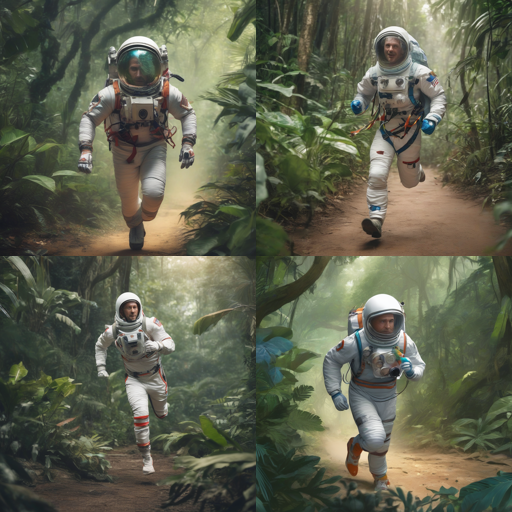

In [6]:
image_grid(image.images, 2, 2)

The results are amazing. Certainly, SDXL is a lot better than Stable Diffusion 1.6.

Let’s write another prompt and generate three images of a monkey playing with fireworks.

  0%|          | 0/25 [00:00<?, ?it/s]

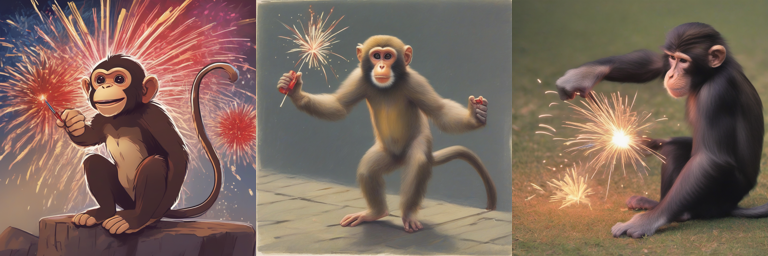

In [7]:
prompt = "A playful monkey handling fireworks with ease."
image = pipe(prompt=prompt, num_inference_steps=25, num_images_per_prompt = 3)
image_grid(image.images, 1, 3)

**Improve the Results with Refiner**

To further improve the image quality and model accuracy, we will use Refiner.

1.   Load SDXL refiner 1.0 using diffusion pipeline.
2.   Generate the image with the base SDXL model. We will change the output type to “latent” which will return the latent representation of the input, rather than the reconstructed image.
3.   Provide the refiner with the prompt and latent representation of
generated image.


model_index.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

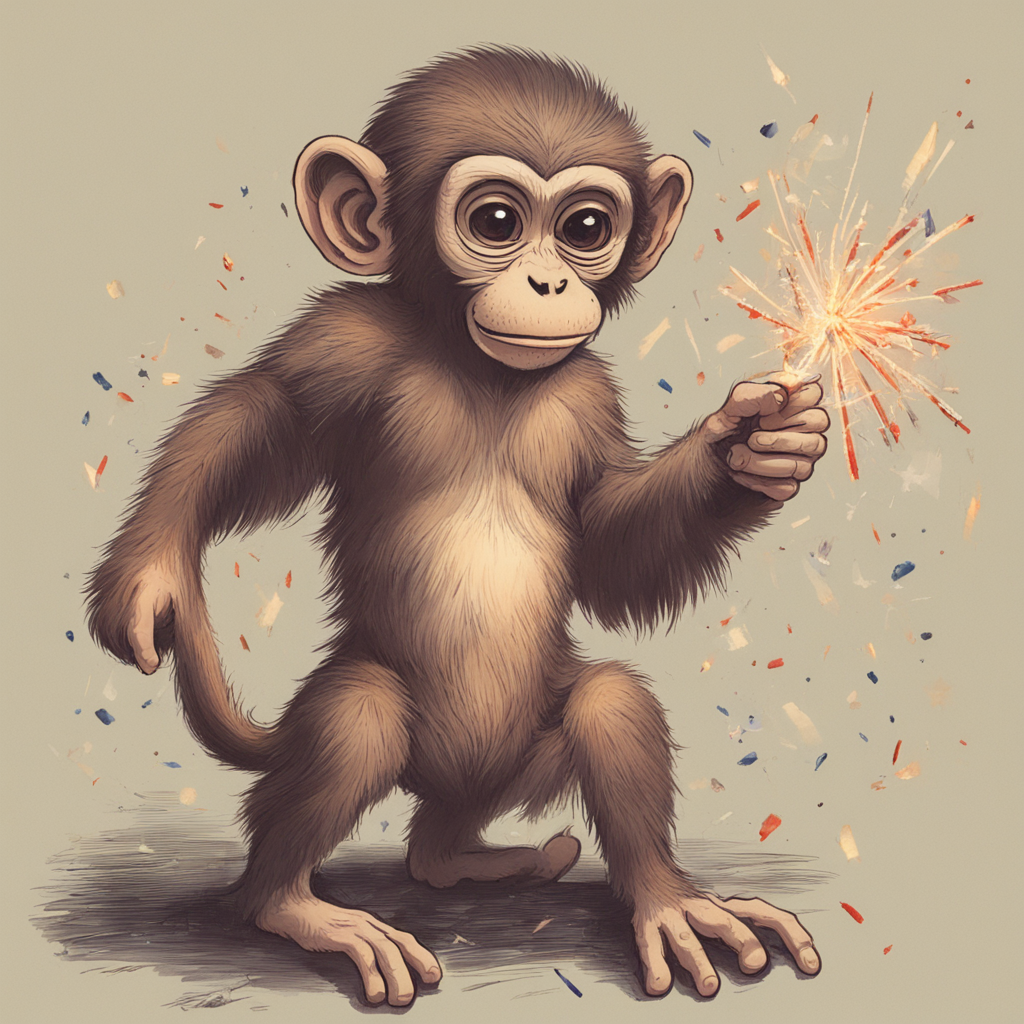

In [8]:
refiner = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-refiner-1.0",
    vae=vae,
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16",
)
refiner.to("cuda")

n_steps = 40
high_noise_frac = 0.7

image = pipe(
    prompt=prompt,
    num_inference_steps=n_steps,
    denoising_end=high_noise_frac,
    output_type="latent",
).images

image = refiner(
    prompt=prompt,
    num_inference_steps=n_steps,
    denoising_start=high_noise_frac,
    image=image,
).images[0]

image


The refined image is high quality and follows the prompt accurately.

**Fine-Tuning SDXL using AutoTrain Advanced**

Fine-tuning SDXL has become much easier with time. Thanks to AutoTrain Advance, we can now fine-tune our model with just one Python script. This Automatic Machine learning library is designed for training and deploying state-of-the-art machine-learning models with minimal code.

You can install the Python package using PIP:

In [9]:
%pip install -U autotrain-advanced

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 248.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 11.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.2/78.2 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.3/341.3 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.4/336.4 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.9/269.9 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.5/225.5 kB 38.3 MB/s eta

If you're interested in fine-tuning the SDXL model with accelerate and transformers, check out the SDXL DreamBoot LoRA Colab Notebook. The notebook is a bit outdated, and you might have to make changes in order to run it properly.

**Setting Up**

Before we run the DreamBooth script, we should set up some variables that we are going to use to run the script.

1.   Name the project.
2.   Location of the base model.
3.   Directory of the dataset.
4. Repo ID for pushing the model to Hugging Face.

In [ ]:
PROJECT_NAME = "Dreambooth_SDXL"
MODEL_NAME = "stabilityai/stable-diffusion-xl-base-1.0"
DATA_DIR = "/kaggle/input/abids-photos"
REPO_ID = "kingabzpro/sdxl-lora-abid"

Next, you will set up a Hugging Face token by using the Kaggle’s Secret feature. Learn how to set up secrets by reading [Mistral 7B Tutorial: Step-by-Step Guide for Using Mistral 7B.](https://www.datacamp.com/tutorial/mistral-7b-tutorial)

In [ ]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HUGGINGFACE_TOKEN")

To view all five images in the Jupyter Notebook, we will load the images using PIL and feed it to our image_grid function.

In [ ]:
from PIL import Image

def image_grid(imgs, rows, cols, resize=256):
    assert len(imgs) == rows * cols

    if resize is not None:
        imgs = [img.resize((resize, resize)) for img in imgs]

    w, h = imgs[0].size
    grid_w, grid_h = cols * w, rows * h
    grid = Image.new("RGB", size=(grid_w, grid_h))

    for i, img in enumerate(imgs):
        x = i % cols * w
        y = i // cols * h
        grid.paste(img, box=(x, y))

    return grid

import glob

We displayed five high-quality images of the author at different locations. Please ensure that all photos are high quality and of similar size.

In [ ]:
imgs = [Image.open(path) for path in glob.glob("/kaggle/input/abids-photos/*.jpg")]
image_grid(imgs, 1, 5)

**AutoTrain Dream Booth Training Script**

It is time to fine-tune our model on these five images using the AutoTrain DreamBooth script.

1.    Provide base model, project name, and data directory.
2.    Ensure the instance prompt is unique, describing the person or the object. Use the person's full name, "Abid Ali Awan," and describe the photo in detail.
3.    Keep the rest of the argument the same to get the best performance.
4.    Provide the Hugging Face access token and repository ID to upload model LoRA adopter to the Hugging Face Hub.


It took 2 hours and 15 minutes to train the model and push the LoRA weights to Hugging Face.

LoRA, short for Low-Rank Adaptation, is a technique that involves adding small trainable layers to an existing model without modifying the original weights.

LoRA is beneficial because it allows the introduction of new concepts, such as art styles, characters, or themes, to the model without requiring extensive computation or memory usage.

Instead of saving a 7GB model file, we will save a LoRA adapter of 23.4MB that will be attached to the base model during inference.

**SDXL Fine-tuned Model Inference**

We will create a diffusion pipeline to generate the image, using a custom VAE decoder and SDXL base model with FP16 precision.

Then, we will load the LoRA weights and add them to the base model using our Hugging Face repo ID.

In the end, we will run the pipeline with the prompt and generate three images.

In [ ]:
from diffusers import DiffusionPipeline, AutoencoderKL, StableDiffusionXLImg2ImgPipeline

import torch

vae = AutoencoderKL.from_pretrained(
    "madebyollin/sdxl-vae-fp16-fix",
    torch_dtype=torch.float16
)
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    vae=vae,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
)
pipe.to("cuda");
pipe.load_lora_weights(REPO_ID, weight_name="pytorch_lora_weights.safetensors")


prompt = "A photo of ABC participating in a marathon."

image = pipe(prompt=prompt, num_inference_steps=25, num_images_per_prompt = 3)
image_grid(image.images, 1, 3)

The results are impressive. We have successfully fine-tuned our model to generate images of the author “  ”.

Let’s try again with another prompt.

In [ ]:
prompt = "A photo of ABC giving a press conference."

image = pipe(prompt=prompt, num_inference_steps=25, num_images_per_prompt = 3)
image_grid(image.images, 1, 3)

**Using Refiner**

In this section, we will improve the generated image with the SDXL Refiner 1.0.

First, we will generate the image using the Stable Diffusion pipeline and provide a manual seed to ensure reproducibility.

In [ ]:
prompt = "A photo of Abid Ali Awan wearing a business suit at an office meeting."

seed = 65
generator = torch.Generator("cuda").manual_seed(seed)
image = pipe(prompt=prompt, num_inference_steps=25, generator=generator).images[0]
image.resize((300, 300))

Next, we will load SDXL refiner and run the refiner pipeline with the same prompt, generator, and generated image.

In [ ]:
refiner = StableDiffusionXLImg2ImgPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-refiner-1.0",
    vae=vae,
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16",
)
refiner.to("cuda");

image = refiner(prompt=prompt, num_inference_steps=25, generator=generator, image=image)
image.images[0].resize((300, 300))